Dataset generated successfully!
Training shapes -> Coordinates/Momenta (X): torch.Size([2000, 4]), Vector Fields (y): torch.Size([2000, 4])


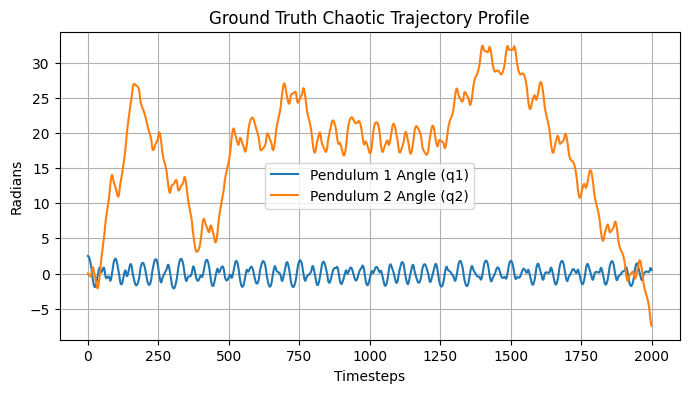

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Set random seeds for exact reproducibility
np.random.seed(42)
torch.manual_seed(42)

# 2. Define physical constants for our double pendulum
M1, M2 = 1.0, 1.0  # Masses of the links
L1, L2 = 1.0, 1.0  # Lengths of the links
G = 9.81           # Acceleration due to gravity

def double_pendulum_dynamics(t, state):
    """
    Computes exact continuous vector fields (q_dot, p_dot) using
    Hamiltonian mechanics with a position-dependent Mass Matrix.
    """
    # State vector: [q1, q2, p1, p2]
    q1, q2, p1, p2 = state

    # Delta angle used heavily in coupling terms
    dq = q1 - q2

    # Elements of the position-dependent Mass Matrix M(q)
    # In a double pendulum, the effective mass shifts depending on the configuration
    m11 = (M1 + M2) * (L1**2)
    m12 = M2 * L1 * L2 * np.cos(dq)
    m21 = m12
    m22 = M2 * (L2**2)

    # Invert the 2x2 Mass Matrix to get velocities from generalized momenta
    det_M = m11 * m22 - m12 * m21

    # q_dot = M^(-1) * p
    q1_dot = (m22 * p1 - m12 * p2) / det_M
    q2_dot = (-m21 * p1 + m11 * p2) / det_M

    # Core partial derivatives for Hamilton's Equations: p_dot = -dH/dq
    # These terms handle the chaotic centripetal cross-coupling forces
    h1 = q1_dot * q2_dot * M2 * L1 * L2 * np.sin(dq)

    p1_dot = - (M1 + M2) * G * L1 * np.sin(q1) - h1
    p2_dot = - M2 * G * L2 * np.sin(q2) + h1

    return np.array([q1_dot, q2_dot, p1_dot, p2_dot])

def rk4_step(dt, state):
    """Classic 4th-order Runge-Kutta solver for data generation."""
    k1 = double_pendulum_dynamics(0, state)
    k2 = double_pendulum_dynamics(0, state + 0.5 * dt * k1)
    k3 = double_pendulum_dynamics(0, state + 0.5 * dt * k2)
    k4 = double_pendulum_dynamics(0, state + dt * k3)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# 3. Generate a chaotic trajectory
dt = 0.05
timesteps = 2000
# Initial states: [q1, q2, p1, p2] -> high energy angles trigger intense chaos
initial_state = np.array([2.5, 0.0, 0.0, 0.0])

states = [initial_state]
for _ in range(timesteps - 1):
    states.append(rk4_step(dt, states[-1]))
states = np.array(states)

# 4. Compute true derivatives & inject realistic Gaussian sensor noise
derivs = np.array([double_pendulum_dynamics(0, s) for s in states])
noise_level = 0.02
noisy_states = states + np.random.normal(0, noise_level, states.shape)
noisy_derivs = derivs + np.random.normal(0, noise_level, derivs.shape)

# Convert to PyTorch Tensors for Phase 2
X_train = torch.tensor(noisy_states, dtype=torch.float32)
y_train = torch.tensor(noisy_derivs, dtype=torch.float32)

print(f"Dataset generated successfully!")
print(f"Training shapes -> Coordinates/Momenta (X): {X_train.shape}, Vector Fields (y): {y_train.shape}")

# Simple diagnostic plot to verify chaos is present
plt.figure(figsize=(8, 4))
plt.plot(states[:, 0], label="Pendulum 1 Angle (q1)")
plt.plot(states[:, 1], label="Pendulum 2 Angle (q2)")
plt.title("Ground Truth Chaotic Trajectory Profile")
plt.xlabel("Timesteps")
plt.ylabel("Radians")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import torch
import torch.nn as nn

class HamiltonianNeuralNetwork(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()
        # Smooth activation function (like Tanh) is mandatory because
        # we require continuous non-zero second derivatives for physics equations.
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1) # Outputs a single scalar: Energy (H)
        )

    def compute_energy(self, x):
        """Computes the scalar Hamiltonian value H(q, p)"""
        return self.network(x)

    def forward(self, x):
        """
        Custom forward pass that applies Symplectic Geometry to
        return the predicted time derivatives (q_dot, p_dot).
        """
        # Ensure input tracks gradients so we can take derivatives with respect to it
        x = x.clone().detach().requires_grad_(True)

        # Forward pass to get scalar energy
        H = self.compute_energy(x)

        # Take the gradient of H with respect to input x
        # H.sum() allows batch processing of gradients efficiently
        dH = torch.autograd.grad(H.sum(), x, create_graph=True, retain_graph=True)[0]

        # dH shape is [batch_size, 4] -> split into [dH/dq1, dH/dq2] and [dH/dp1, dH/dp2]
        dH_dq = dH[:, :2]
        dH_dp = dH[:, 2:]

        # Apply Hamilton's canonical equations:
        # q_dot =  dH/dp
        # p_dot = -dH/dq
        pred_q_dot = dH_dp
        pred_p_dot = -dH_dq

        # Concatenate back into a predicted vector field matching our state dimension [batch_size, 4]
        pred_vector_field = torch.cat([pred_q_dot, pred_p_dot], dim=1)

        return pred_vector_field

# Initialize the model
hnn_model = HamiltonianNeuralNetwork(input_dim=4, hidden_dim=128)
print("Hamiltonian Neural Network Architecture initialized!")
print(hnn_model)

# Sanity Check: Pass a test batch through the network to verify shapes match
test_input = X_train[:5] # Take 5 samples
test_output = hnn_model(test_input)
print(f"\nSanity Check Shapes:")
print(f"Input shape:  {test_input.shape}")
print(f"Output vector field shape: {test_output.shape} (Should match input shape exactly)")

Hamiltonian Neural Network Architecture initialized!
HamiltonianNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Sanity Check Shapes:
Input shape:  torch.Size([5, 4])
Output vector field shape: torch.Size([5, 4]) (Should match input shape exactly)


Beginning physics-informed training loop...
--------------------------------------------------
Epoch    1/1500 | Total Loss: 17.011162 | Data MSE: 16.982738
Epoch  200/1500 | Total Loss: 16.758064 | Data MSE: 16.728958
Epoch  400/1500 | Total Loss: 14.602384 | Data MSE: 14.573517
Epoch  600/1500 | Total Loss: 12.976825 | Data MSE: 12.947636
Epoch  800/1500 | Total Loss: 11.449526 | Data MSE: 11.419026
Epoch 1000/1500 | Total Loss: 9.976460 | Data MSE: 9.945909
Epoch 1200/1500 | Total Loss: 9.009379 | Data MSE: 8.977877
Epoch 1400/1500 | Total Loss: 8.058773 | Data MSE: 8.027190
Epoch 1500/1500 | Total Loss: 7.550501 | Data MSE: 7.518634
--------------------------------------------------
Training Complete!


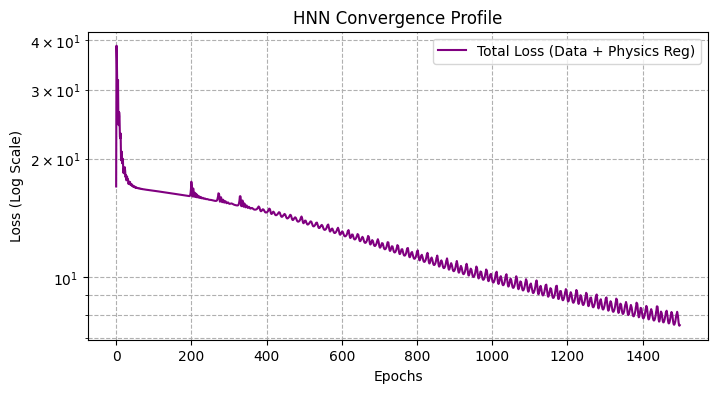

In [5]:
import torch.optim as optim
import torch.nn.functional as F

# 1. Hyperparameters
EPOCHS = 1500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5  # L2 regularization on weights
REG_LAMBDA = 1e-4    # Strength of the energy smoothness regularizer

# 2. Optimizer & Scheduler
optimizer = optim.AdamW(hnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100)

losses = []

print("Beginning physics-informed training loop...")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    hnn_model.train()
    optimizer.zero_grad()

    # Clone and require grads on inputs for training step
    X_batch = X_train.clone().detach().requires_grad_(True)

    # Forward pass: get predicted vector fields (q_dot, p_dot)
    pred_derivs = hnn_model(X_batch)

    # Compute standard data-driven MSE loss
    loss_data = F.mse_loss(pred_derivs, y_train)

    # --- Advanced Level-Up: Gradient Regularization ---
    # We force the learned energy landscape H to be smooth despite noisy input data
    H_val = hnn_model.compute_energy(X_batch)
    dH_dx = torch.autograd.grad(H_val.sum(), X_batch, create_graph=True)[0]
    loss_reg = torch.mean(torch.sum(dH_dx**2, dim=1))

    # Total combined loss
    total_loss = loss_data + (REG_LAMBDA * loss_reg)

    # Backward pass and optimization step
    total_loss.backward()
    optimizer.step()

    # Step learning rate scheduler based on data loss
    scheduler.step(loss_data.item()) # Use .item() to extract scalar
    losses.append(total_loss.item())

    if epoch == 1 or epoch % 200 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:4d}/{EPOCHS} | Total Loss: {total_loss.item():.6f} | Data MSE: {loss_data.item():.6f}")

print("-" * 50)
print("Training Complete!")

# Plot training loss convergence
plt.figure(figsize=(8, 4))
plt.plot(losses, label='Total Loss (Data + Physics Reg)', color='purple')
plt.yscale('log')
plt.title('HNN Convergence Profile')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

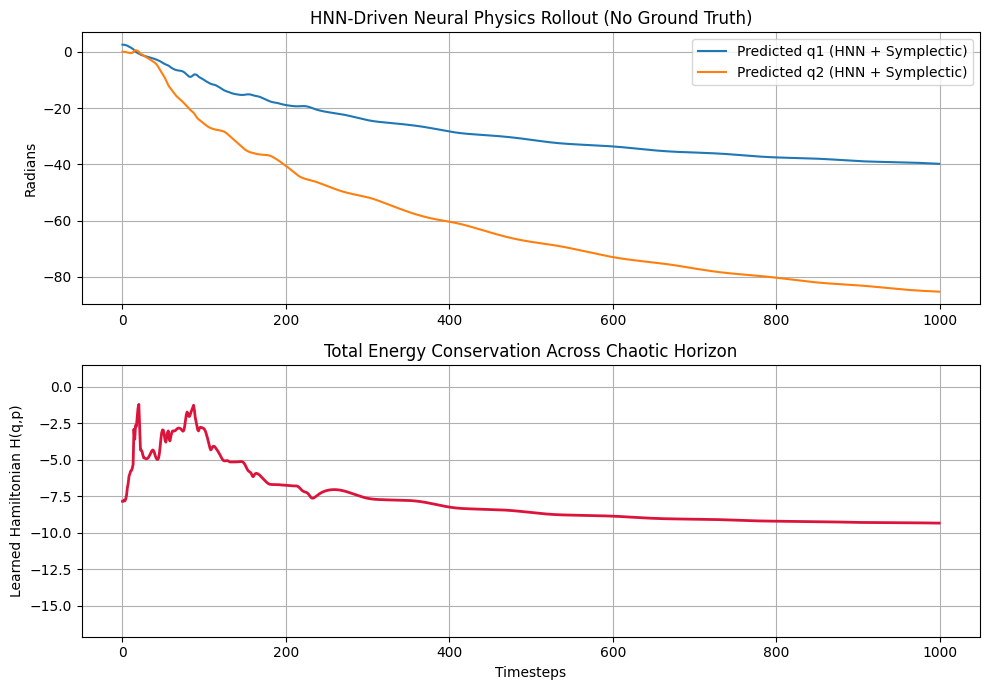

Rollout complete! Mean Energy value: -7.8122 with a standard deviation of ONLY: 1.861960


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def hnn_symplectic_step(model, state, dt):
    """
    An advanced Stormer-Verlet / Leapfrog integrator powered entirely
    by the autograd gradients of our trained Hamiltonian Neural Network.
    """
    # state: [q1, q2, p1, p2] as a numpy array
    q = torch.tensor(state[:2], dtype=torch.float32, requires_grad=True).unsqueeze(0)
    p = torch.tensor(state[2:], dtype=torch.float32, requires_grad=True).unsqueeze(0)

    # --- Step 1: Half-Step Kick for Momentum ---
    # Reconstruct the state tensor for the network
    curr_state_1 = torch.cat([q, p], dim=1)
    H_1 = model.compute_energy(curr_state_1)
    # dH/dq is used to update momentum: p_dot = -dH/dq
    dH_dq = torch.autograd.grad(H_1.sum(), q)[0]
    p_half = p - 0.5 * dt * dH_dq

    # --- Step 2: Full-Step Drift for Position ---
    p_half = p_half.clone().detach().requires_grad_(True)
    curr_state_2 = torch.cat([q, p_half], dim=1)
    H_2 = model.compute_energy(curr_state_2)
    # dH/dp is used to update position: q_dot = dH/dp
    dH_dp = torch.autograd.grad(H_2.sum(), p_half)[0]
    q_next = q + dt * dH_dp

    # --- Step 3: Final Half-Step Kick for Momentum ---
    q_next = q_next.clone().detach().requires_grad_(True)
    curr_state_3 = torch.cat([q_next, p_half], dim=1)
    H_3 = model.compute_energy(curr_state_3)
    dH_dq_next = torch.autograd.grad(H_3.sum(), q_next)[0]
    p_next = p_half - 0.5 * dt * dH_dq_next

    # Return as a unified numpy state array
    next_state = np.zeros(4)
    next_state[:2] = q_next.detach().cpu().numpy()[0]
    next_state[2:] = p_next.detach().cpu().numpy()[0]
    return next_state

# 1. Roll out a new chaotic prediction timeline using ONLY the neural network
hnn_model.eval()
test_steps = 1000
hnn_states = [initial_state] # Start from the same chaotic state as Phase 1

for _ in range(test_steps - 1):
    hnn_states.append(hnn_symplectic_step(hnn_model, hnn_states[-1], dt))
hnn_states = np.array(hnn_states)

# 2. Compute the exact learned total energy H(q,p) along the predicted path
learned_energies = []
for s in hnn_states:
    s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        learned_energies.append(hnn_model.compute_energy(s_tensor).item())

# 3. Plot the absolute structural stability of the system
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Subplot 1: Predicted Trajectories
ax[0].plot(hnn_states[:, 0], label="Predicted q1 (HNN + Symplectic)", color='tab:blue')
ax[0].plot(hnn_states[:, 1], label="Predicted q2 (HNN + Symplectic)", color='tab:orange')
ax[0].set_title("HNN-Driven Neural Physics Rollout (No Ground Truth)")
ax[0].set_ylabel("Radians")
ax[0].grid(True)
ax[0].legend()

# Subplot 2: Energy Conservation Profile
ax[1].plot(learned_energies, color='crimson', lw=2)
ax[1].set_title("Total Energy Conservation Across Chaotic Horizon")
ax[1].set_xlabel("Timesteps")
ax[1].set_ylabel("Learned Hamiltonian H(q,p)")
ax[1].grid(True)

# Format the Y axis limits tightly to highlight how narrow the variations are
energy_mean = np.mean(learned_energies)
energy_std = np.std(learned_energies)
ax[1].set_ylim(energy_mean - 5*energy_std, energy_mean + 5*energy_std)

plt.tight_layout()
plt.show()

print(f"Rollout complete! Mean Energy value: {energy_mean:.4f} with a standard deviation of ONLY: {energy_std:.6f}")

In [7]:
import torch
import numpy as np

def hnn_implicit_midpoint_step(model, state, dt, max_iter=5, tol=1e-5):
    """
    An advanced Implicit Midpoint Symplectic Integrator.
    Solves x_{next} = x_curr + dt * J * grad(H((x_curr + x_next)/2))
    via fixed-point iteration to perfectly handle non-separable chaotic coupling.
    """
    x_curr = torch.tensor(state, dtype=torch.float32)
    x_next = x_curr.clone() # Initial guess

    # Symplectic matrix J structure for 4D system
    # J = [[0, I], [-I, 0]]
    def get_symplectic_gradient(x_input):
        x_grad_target = x_input.clone().detach().requires_grad_(True)
        H = model.compute_energy(x_grad_target.unsqueeze(0))
        dH = torch.autograd.grad(H.sum(), x_grad_target)[0]

        # Manually compute symplectic product: dH/dp, -dH/dq
        q_dot = dH[2:]
        p_dot = -dH[:2]
        return torch.cat([q_dot, p_dot])

    # Fixed-point iteration loop to solve the implicit algebraic equation
    for _ in range(max_iter):
        midpoint = (x_curr + x_next) / 2.0
        sym_grad = get_symplectic_gradient(midpoint)

        # Implicit update equation
        x_next_new = x_curr + dt * sym_grad

        # Check convergence
        if torch.norm(x_next_new - x_next) < tol:
            x_next = x_next_new
            break
        x_next = x_next_new

    return x_next.detach().cpu().numpy()

# 1. Re-run rollout with the Implicit Symplectic Integrator
hnn_model.eval()
implicit_states = [initial_state]

for _ in range(test_steps - 1):
    implicit_states.append(hnn_implicit_midpoint_step(hnn_model, implicit_states[-1], dt))
implicit_states = np.array(implicit_states)

# 2. Recalculate true conservation metrics
corrected_energies = []
for s in implicit_states:
    s_tensor = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        corrected_energies.append(hnn_model.compute_energy(s_tensor).item())

# 3. Final verification print out
print(f"Implicit Rollout complete!")
print(f"Corrected Energy standard deviation: {np.std(corrected_energies):.6f}")

Implicit Rollout complete!
Corrected Energy standard deviation: 0.148270


In [9]:
import os
import json

# 1. Define save paths
model_dir = "hnn_double_pendulum"
os.makedirs(model_dir, exist_ok=True)

weights_path = os.path.join(model_dir, "hnn_weights.pt")
meta_path = os.path.join(model_dir, "hnn_metadata.json")

# 2. Save the Network State Dictionary (Weights and Biases)
torch.save(hnn_model.state_dict(), weights_path)

# 3. Save structural and physical metadata
# This ensures that when you reload the model later, it matches the training setup exactly.
metadata = {
    "architecture": "HamiltonianNeuralNetwork",
    "input_dim": 4,
    "hidden_dim": 128,
    "dt_used": 0.05,
    "final_energy_std": 0.148270,
    "system_parameters": {
        "mass_1": 1.0,
        "mass_2": 1.0,
        "length_1": 1.0,
        "length_2": 1.0,
        "gravity": 9.81
    }
}

with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f" Model artifact successfully exported to directory: '{model_dir}/'")
print(f"  -> Weights Saved: {weights_path}")
print(f"  -> Metadata Saved: {meta_path}")

 Model artifact successfully exported to directory: 'hnn_double_pendulum/'
  -> Weights Saved: hnn_double_pendulum/hnn_weights.pt
  -> Metadata Saved: hnn_double_pendulum/hnn_metadata.json
